In [2]:
# Cell 1: Basic Imports
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


In [3]:
# Cell 2: Configuration
class CFG:
    seed = 42
    sequence_length = 200
    batch_size = 8
    epochs = 3
    learning_rate = 5e-6
    
    # Data paths
    train_path = '/kaggle/input/llm-detect-ai-generated-text/train_essays.csv'
    ext_path1 = '/kaggle/input/daigt-proper-train-dataset/train_drcat_04.csv'
    ext_path2 = '/kaggle/input/argugpt/argugpt.csv'

# Set seed
tf.random.set_seed(CFG.seed)
np.random.seed(CFG.seed)

In [4]:
# Cell 3: Load and Prepare Data
# Load main dataset
main_df = pd.read_csv(CFG.train_path)
main_df['label'] = main_df['generated'].copy()

# Load external datasets
ext_df1 = pd.read_csv(CFG.ext_path1)
ext_df2 = pd.read_csv(CFG.ext_path2)[['text', 'model']]
ext_df2.rename(columns={'model': 'source'}, inplace=True)
ext_df2['label'] = 1

# Combine datasets
ext_df = pd.concat([
    ext_df1[ext_df1.source == 'persuade_corpus'].sample(10000, random_state=CFG.seed),
    ext_df1[ext_df1.source != 'persuade_corpus'],
    ext_df2
], ignore_index=True)

# Combine all data
all_data = pd.concat([
    main_df[['text', 'label']],
    ext_df[['text', 'label']]
], ignore_index=True)

print(f"Total samples: {len(all_data):,}")

Total samples: 33,626


In [5]:
# Cell 4: Create Balanced Dataset (12K total)
# Get real and fake samples
real_samples = all_data[all_data.label == 0]
fake_samples = all_data[all_data.label == 1]

# Take 6000 from each class
balanced_real = real_samples.sample(6000, random_state=CFG.seed)
balanced_fake = fake_samples.sample(6000, random_state=CFG.seed)

# Combine and shuffle
balanced_data = pd.concat([balanced_real, balanced_fake], ignore_index=True)
balanced_data = balanced_data.sample(frac=1, random_state=CFG.seed)

print(f"Balanced dataset: {len(balanced_data):,} samples")
print("Class distribution:")
print(balanced_data.label.value_counts())

Balanced dataset: 12,000 samples
Class distribution:
label
0    6000
1    6000
Name: count, dtype: int64


In [6]:
# Cell 5: Train/Validation/Test Split
# Split: 70% train, 10% validation, 20% test
train_data, temp_data = train_test_split(
    balanced_data, 
    test_size=0.3, 
    random_state=CFG.seed,
    stratify=balanced_data.label
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.666,  # 20% of total = 0.666 * 30%
    random_state=CFG.seed,
    stratify=temp_data.label
)

print(f"Training samples: {len(train_data):,}")
print(f"Validation samples: {len(val_data):,}") 
print(f"Test samples: {len(test_data):,}")

Training samples: 8,400
Validation samples: 1,202
Test samples: 2,398


In [7]:
# Cell 6: Simple Data Pipeline
def create_dataset(texts, labels, batch_size=32, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((texts, labels))
    
    if shuffle:
        dataset = dataset.shuffle(1000, seed=CFG.seed)
    
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Create datasets
train_ds = create_dataset(
    train_data.text.values, 
    train_data.label.values,
    batch_size=CFG.batch_size,
    shuffle=True
)

val_ds = create_dataset(
    val_data.text.values,
    val_data.label.values, 
    batch_size=CFG.batch_size
)

test_ds = create_dataset(
    test_data.text.values,
    test_data.label.values,
    batch_size=CFG.batch_size
)

print("Datasets created successfully!")

I0000 00:00:1764430056.600168      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764430056.600845      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully!


In [9]:
import os
# Cell 7: Build Simple Model
def build_model():
    # Import here to avoid version conflicts
    from tensorflow import keras
    
    # Use Keras 3 with TensorFlow backend
    os.environ["KERAS_BACKEND"] = "tensorflow"
    
    # Try to import keras_nlp, fallback to transformers
    try:
        import keras_nlp
        print("Using KerasNLP DeBERTa")
        
        model = keras_nlp.models.DebertaV3Classifier.from_preset(
            "deberta_v3_base_en",
            num_classes=1
        )
        
    except ImportError:
        print("KerasNLP not available, using Hugging Face Transformers")
        from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
        
        model = TFAutoModelForSequenceClassification.from_pretrained(
            "microsoft/deberta-v3-base",
            num_labels=1
        )
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=CFG.learning_rate),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", from_logits=True)
        ]
    )
    
    return model

model = build_model()
print("Model built successfully!")
model.summary()

Using KerasNLP DeBERTa
Model built successfully!


Preprocessor: "deberta_v3_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ deberta_v3_tokenizer (DebertaV3Tokenizer)                     │                      Vocab size: 128,001 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "deberta_v3_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deberta_v3_backbone           │ (None, None, 768)         │     183,831,552 │ padding_mask[0][0],        │
│ (DebertaV3Backbone)           │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ deberta_v3_backbone[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 1)                 │             769 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 184,422,913 (703.52 MB)

 Trainable params: 184,422,913 (703.52 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Cell 7: Build Simple Model
def build_model():
    # Import here to avoid version conflicts
    from tensorflow import keras
    
    # Use Keras 3 with TensorFlow backend
    os.environ["KERAS_BACKEND"] = "tensorflow"
    
    # Try to import keras_nlp, fallback to transformers
    try:
        import keras_nlp
        print("Using KerasNLP DeBERTa")
        
        model = keras_nlp.models.DebertaV3Classifier.from_preset(
            "deberta_v3_base_en",
            num_classes=1
        )
        
    except ImportError:
        print("KerasNLP not available, using Hugging Face Transformers")
        from transformers import TFAutoModelForSequenceClassification, AutoTokenizer
        
        model = TFAutoModelForSequenceClassification.from_pretrained(
            "microsoft/deberta-v3-base",
            num_labels=1
        )
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=CFG.learning_rate),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", from_logits=True)
        ]
    )
    
    return model

model = build_model()
print("Model built successfully!")
model.summary()

Using KerasNLP DeBERTa
Model built successfully!


Preprocessor: "deberta_v3_text_classifier_preprocessor_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ deberta_v3_tokenizer (DebertaV3Tokenizer)                     │                      Vocab size: 128,001 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "deberta_v3_text_classifier_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ deberta_v3_backbone           │ (None, None, 768)         │     183,831,552 │ padding_mask[0][0],        │
│ (DebertaV3Backbone)           │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item_1 (GetItem)          │ (None, 768)               │               0 │ deberta_v3_backbone[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dropout (Dropout)      │ (None, 768)               │               0 │ get_item_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ pooled_dropout[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 1)                 │             769 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 184,422,913 (703.52 MB)

 Trainable params: 184,422,913 (703.52 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Cell 8: Train Model
print("Starting training...")

# Simple callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        verbose=1
    )
]

# Calculate steps
steps_per_epoch = len(train_data) // CFG.batch_size
validation_steps = len(val_data) // CFG.batch_size

# Train
history = model.fit(
    train_ds,
    epochs=CFG.epochs,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/3


I0000 00:00:1764430189.784317     116 service.cc:148] XLA service 0x7c112c0067c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764430189.784778     116 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764430189.784803     116 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764430196.505721     116 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764430235.782278     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9018 - auc: 0.9705 - loss: 0.1866

1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1461s 1s/step - accuracy: 0.9018 - auc: 0.9705 - loss: 0.1865 - val_accuracy: 0.9950 - val_auc: 0.9999 - val_loss: 0.0104 - learning_rate: 5.0000e-06
Epoch 2/3
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9955 - auc: 0.9988 - loss: 0.0194
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1362s 1s/step - accuracy: 0.9955 - auc: 0.9988 - loss: 0.0194 - val_accuracy: 0.9967 - val_auc: 0.9999 - val_loss: 0.0110 - learning_rate: 5.0000e-06
Epoch 3/3
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9977 - auc: 0.9996 - loss: 0.0093


Epoch 3: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1371s 1s/step - accuracy: 0.9977 - auc: 0.9996 - loss: 0.0093 - val_accuracy: 0.9950 - val_auc: 1.0000 - val_loss: 0.0158 - learning_rate: 2.5000e-06
Training completed!


In [12]:
# Cell 9: Evaluate on Test Set
print("Evaluating on test set...")

# Load best model
try:
    model.load_weights('best_model.h5')
    print("Loaded best model")
except:
    print("Using final model")

# Predict
test_predictions = model.predict(test_ds)
test_pred_proba = tf.sigmoid(test_predictions).numpy().squeeze()
test_pred_binary = (test_pred_proba > 0.5).astype(int)

# Calculate metrics
test_accuracy = accuracy_score(test_data.label.values, test_pred_binary)
test_f1 = f1_score(test_data.label.values, test_pred_binary)
test_auc = roc_auc_score(test_data.label.values, test_pred_proba)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"AUC:       {test_auc:.4f}")
print("="*50)

Evaluating on test set...
Loaded best model
300/300 ━━━━━━━━━━━━━━━━━━━━ 139s 443ms/step

TEST SET RESULTS
Accuracy:  0.9937
F1-Score:  0.9938
AUC:       0.9989


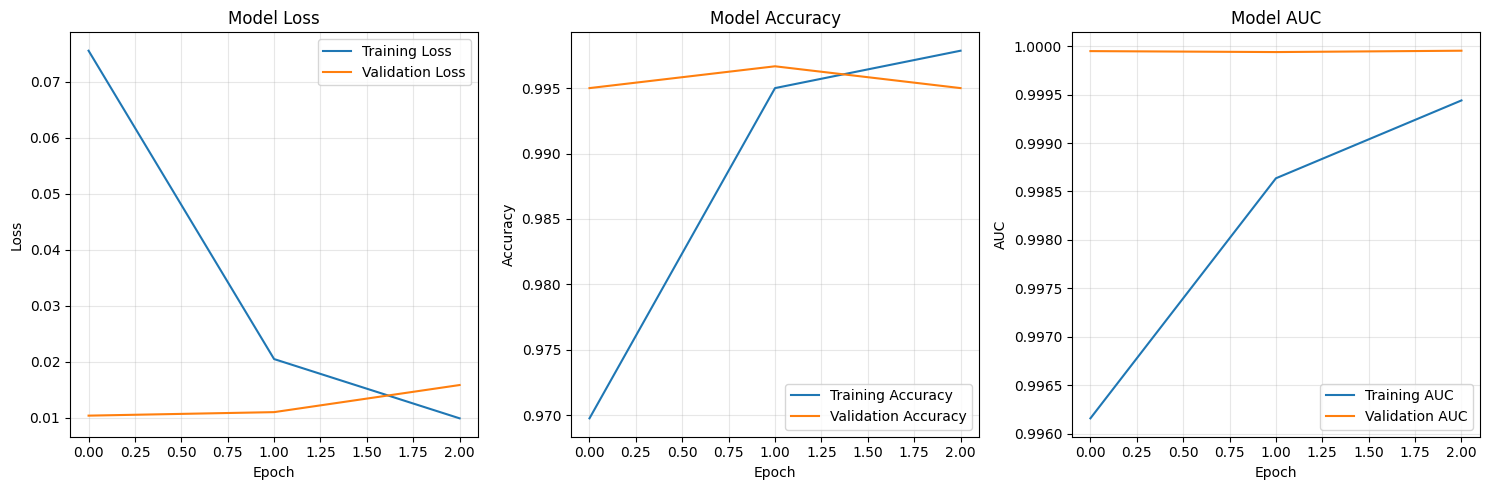


Best Epoch: 3
Best Validation AUC: 1.0000


In [13]:
# Cell 10: Plot Results
# Plot training history
plt.figure(figsize=(15, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# AUC
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best epoch
best_epoch = np.argmax(history.history['val_auc'])
print(f"\nBest Epoch: {best_epoch + 1}")
print(f"Best Validation AUC: {history.history['val_auc'][best_epoch]:.4f}")

In [14]:
# Cell 11: Sample Predictions
print("Sample Predictions from Test Set:")
print("="*60)

sample_indices = np.random.choice(len(test_data), 5, replace=False)

for i, idx in enumerate(sample_indices):
    sample = test_data.iloc[idx]
    true_label = "FAKE" if sample.label == 1 else "REAL"
    pred_prob = test_pred_proba[idx]
    pred_label = "FAKE" if pred_prob > 0.5 else "REAL"
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob
    
    print(f"\nSample {i+1}:")
    print(f"Text: {sample.text[:100]}...")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label} (confidence: {confidence:.3f})")
    print("-" * 40)

Sample Predictions from Test Set:

Sample 1:
Text: How do you feel about our voting system today? Today our current voting system consists of electoral...
True: REAL
Pred: REAL (confidence: 0.999)
----------------------------------------

Sample 2:
Text: Technically, students spend seven hours in school and seventeen hours at home regardless of what tim...
True: REAL
Pred: REAL (confidence: 0.999)
----------------------------------------

Sample 3:
Text: As more and more students are working during the school year, either to earn extra spending money or...
True: FAKE
Pred: FAKE (confidence: 1.000)
----------------------------------------

Sample 4:
Text: " How village people get education "

A village have a school and they are diside learning the peopl...
True: REAL
Pred: REAL (confidence: 0.999)
----------------------------------------

Sample 5:
Text: Most advertisements make products seem much better than they really are. I agree with this statement...
True: FAKE
Pred: FAKE (confid